# librerias

In [1]:
#librerias
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
color_pal = sns.color_palette()
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import joblib

# Inicio

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/playground-series-s5e8/sample_submission.csv
/kaggle/input/playground-series-s5e8/train.csv
/kaggle/input/playground-series-s5e8/test.csv


In [3]:
np.random.seed(42)


In [4]:
#DataFrame with training data
train_df = pd.read_csv('/kaggle/input/playground-series-s5e8/train.csv')
#DataFrame with testing data
test_df = pd.read_csv('/kaggle/input/playground-series-s5e8/test.csv')

print(train_df.head(5))

   id  age          job  marital  education default  balance housing loan  \
0   0   42   technician  married  secondary      no        7      no   no   
1   1   38  blue-collar  married  secondary      no      514      no   no   
2   2   36  blue-collar  married  secondary      no      602     yes   no   
3   3   27      student   single  secondary      no       34     yes   no   
4   4   26   technician  married  secondary      no      889     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome  y  
0  cellular   25   aug       117         3     -1         0  unknown  0  
1   unknown   18   jun       185         1     -1         0  unknown  0  
2   unknown   14   may       111         2     -1         0  unknown  0  
3   unknown   28   may        10         2     -1         0  unknown  0  
4  cellular    3   feb       902         1     -1         0  unknown  1  


In [5]:
print(train_df.describe(include='all'))
print(train_df.info())

                   id            age         job  marital  education default  \
count   750000.000000  750000.000000      750000   750000     750000  750000   
unique            NaN            NaN          12        3          4       2   
top               NaN            NaN  management  married  secondary      no   
freq              NaN            NaN      175541   480759     401683  737151   
mean    374999.500000      40.926395         NaN      NaN        NaN     NaN   
std     216506.495284      10.098829         NaN      NaN        NaN     NaN   
min          0.000000      18.000000         NaN      NaN        NaN     NaN   
25%     187499.750000      33.000000         NaN      NaN        NaN     NaN   
50%     374999.500000      39.000000         NaN      NaN        NaN     NaN   
75%     562499.250000      48.000000         NaN      NaN        NaN     NaN   
max     749999.000000      95.000000         NaN      NaN        NaN     NaN   

              balance housing    loan  

In [6]:
print(test_df.describe(include='all'))
print(test_df.info())

                   id            age         job  marital  education default  \
count   250000.000000  250000.000000      250000   250000     250000  250000   
unique            NaN            NaN          12        3          4       2   
top               NaN            NaN  management  married  secondary      no   
freq              NaN            NaN       58636   160412     133724  245843   
mean    874999.500000      40.932332         NaN      NaN        NaN     NaN   
std      72168.927986      10.081613         NaN      NaN        NaN     NaN   
min     750000.000000      18.000000         NaN      NaN        NaN     NaN   
25%     812499.750000      33.000000         NaN      NaN        NaN     NaN   
50%     874999.500000      39.000000         NaN      NaN        NaN     NaN   
75%     937499.250000      48.000000         NaN      NaN        NaN     NaN   
max     999999.000000      95.000000         NaN      NaN        NaN     NaN   

              balance housing    loan  

In [7]:
print('job ',train_df.job .unique())
print('marital', train_df.marital.unique())
print('education',train_df.education.unique())
print('housing', train_df.housing.unique())
print('loan  ',train_df.loan.unique())
print('contact', train_df.contact.unique())
print('month',train_df.month.unique())
print('poutcome',train_df.poutcome.unique())
print('y',train_df.y.unique())

job  ['technician' 'blue-collar' 'student' 'admin.' 'management' 'entrepreneur'
 'self-employed' 'unknown' 'services' 'retired' 'housemaid' 'unemployed']
marital ['married' 'single' 'divorced']
education ['secondary' 'primary' 'tertiary' 'unknown']
housing ['no' 'yes']
loan   ['no' 'yes']
contact ['cellular' 'unknown' 'telephone']
month ['aug' 'jun' 'may' 'feb' 'apr' 'nov' 'jul' 'jan' 'oct' 'mar' 'sep' 'dec']
poutcome ['unknown' 'other' 'failure' 'success']
y [0 1]


In [8]:
print('job ',test_df.job .unique())
print('marital', test_df.marital.unique())
print('education',test_df.education.unique())
print('housing', test_df.housing.unique())
print('loan  ',test_df.loan.unique())
print('contact', test_df.contact.unique())
print('month',test_df.month.unique())
print('poutcome',test_df.poutcome.unique())

job  ['blue-collar' 'management' 'self-employed' 'technician' 'services'
 'retired' 'entrepreneur' 'admin.' 'housemaid' 'unemployed' 'student'
 'unknown']
marital ['married' 'single' 'divorced']
education ['secondary' 'tertiary' 'primary' 'unknown']
housing ['yes' 'no']
loan   ['no' 'yes']
contact ['unknown' 'cellular' 'telephone']
month ['may' 'apr' 'jul' 'jan' 'feb' 'aug' 'nov' 'jun' 'sep' 'oct' 'mar' 'dec']
poutcome ['unknown' 'other' 'failure' 'success']


In [9]:
# Paso la variable categórica month a númerica
# Diccionario de mapeo
meses_a_numero = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4,
    'may': 5, 'jun': 6, 'jul': 7, 'aug': 8,
    'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}

train_df['month']=train_df['month'].replace(meses_a_numero).astype(int)
test_df['month']=test_df['month'].replace(meses_a_numero).astype(int)

/tmp/ipykernel_17/3509941815.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df['month']=train_df['month'].replace(meses_a_numero).astype(int)
/tmp/ipykernel_17/3509941815.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df['month']=test_df['month'].replace(meses_a_numero).astype(int)


# Análisis de variables

### Age

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


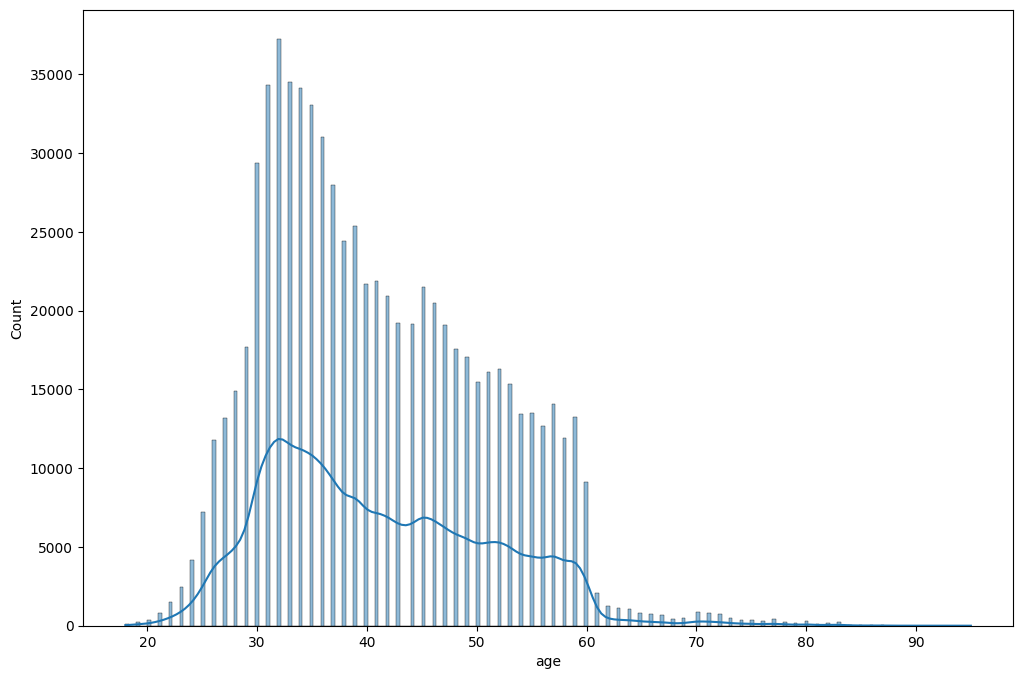

In [10]:

plt.figure(figsize=(12,8))
sns.histplot(data=train_df,
             x='age',
             color=color_pal[0],
             kde=True)
plt.show()

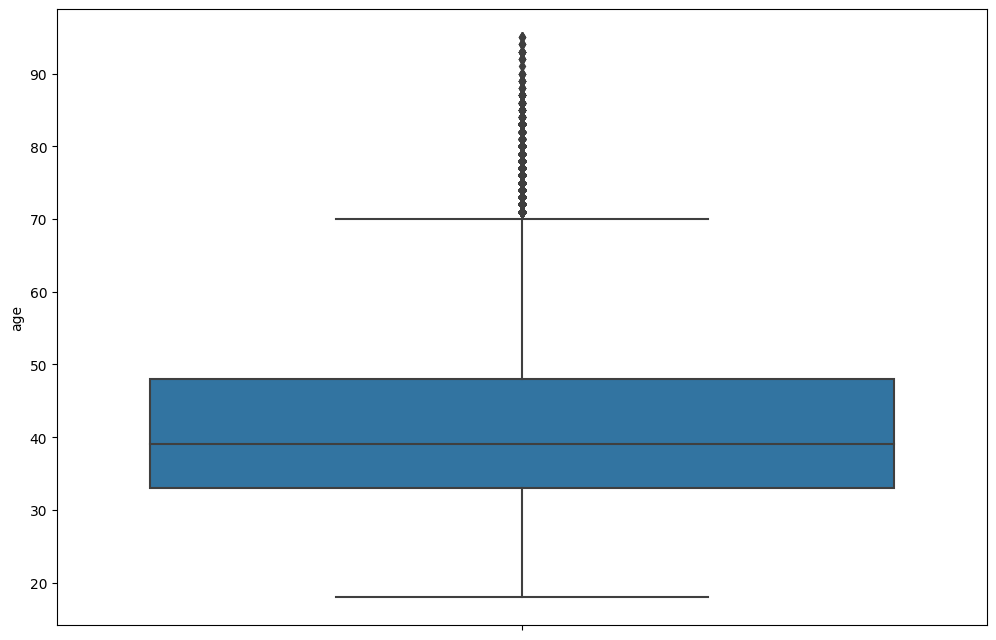

In [11]:
#Gráfico
plt.figure(figsize=(12,8))
sns.boxplot( y='age', data=train_df)
plt.show()


### Balance

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


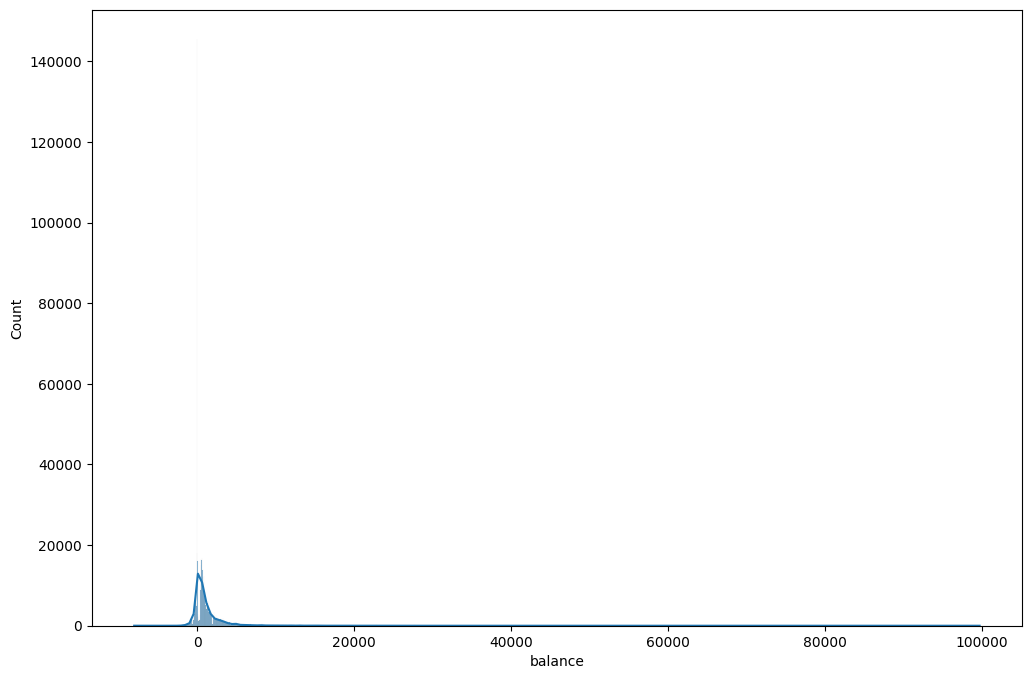

In [12]:
plt.figure(figsize=(12,8))
sns.histplot(data=train_df,
             x='balance',
             color=color_pal[0],
             kde=True)
plt.show()

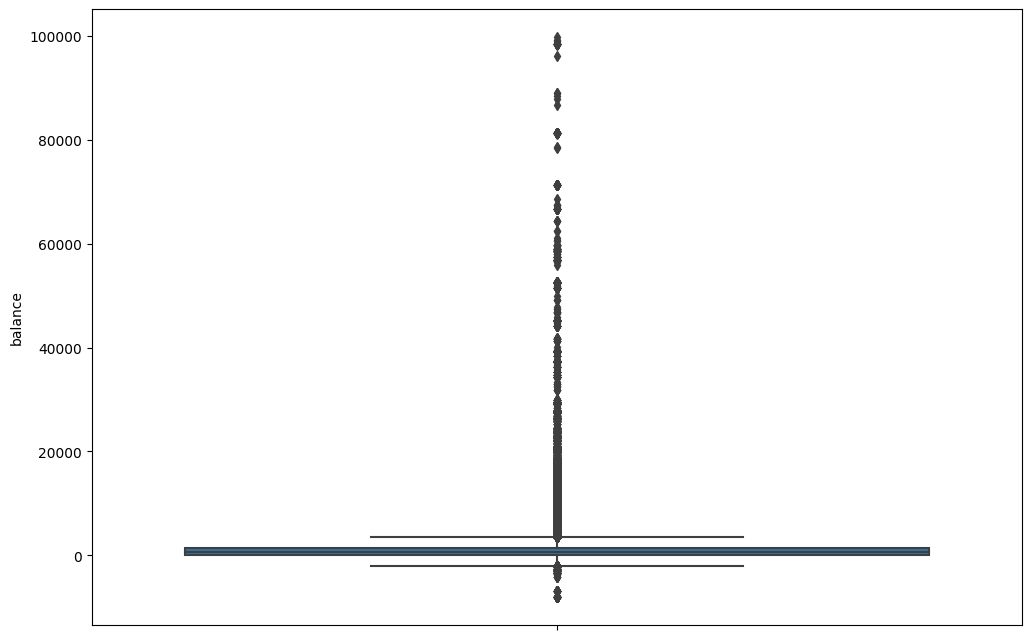

In [13]:
plt.figure(figsize=(12,8))
sns.boxplot( y='balance', data=train_df)
plt.show()

In [14]:
print(train_df.balance.nsmallest(10))
print(train_df.balance.nlargest(10))

18232    -8019
20822    -8019
47459    -8019
55214    -8019
55411    -8019
64574    -8019
99349    -8019
110354   -8019
120322   -8019
126457   -8019
Name: balance, dtype: int64
453989    99717
213252    99218
464263    98942
49547     98418
236770    98418
8578      98417
10392     98417
10440     98417
30594     98417
35381     98417
Name: balance, dtype: int64


In [15]:
train_df['balance_normalized'], lmbda= stats.yeojohnson(train_df['balance'])
test_df['balance_normalized'], lmbda= stats.yeojohnson(test_df['balance'])

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


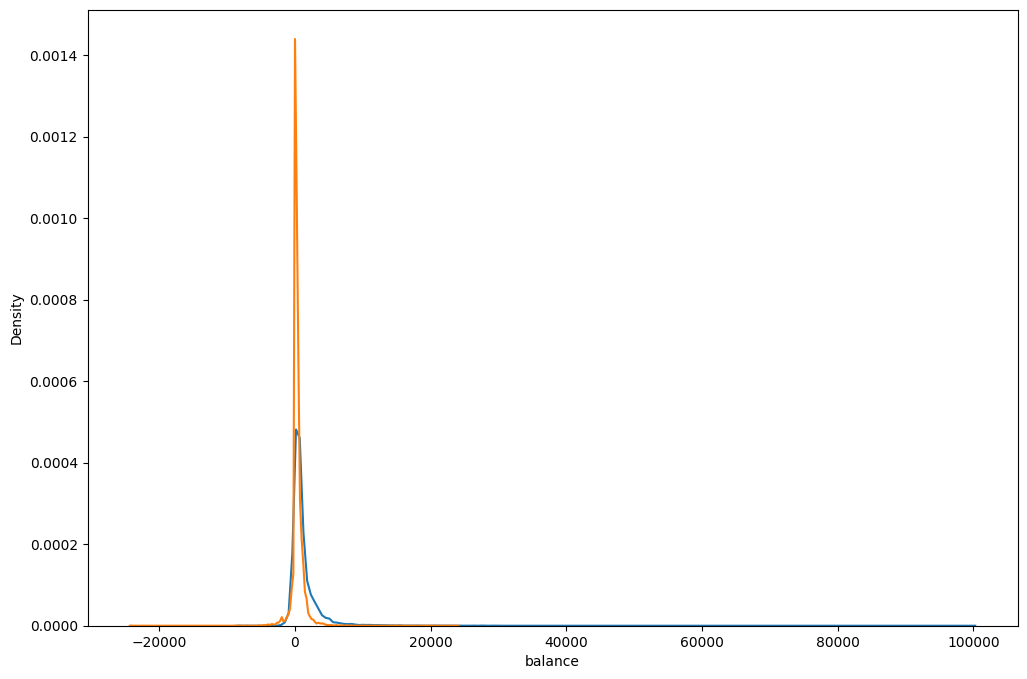

In [16]:
plt.figure(figsize=(12,8))
sns.kdeplot(data=train_df, x='balance', color=color_pal[0]) #azul
sns.kdeplot(data=train_df, x='balance_normalized', color=color_pal[1]) #naranja
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


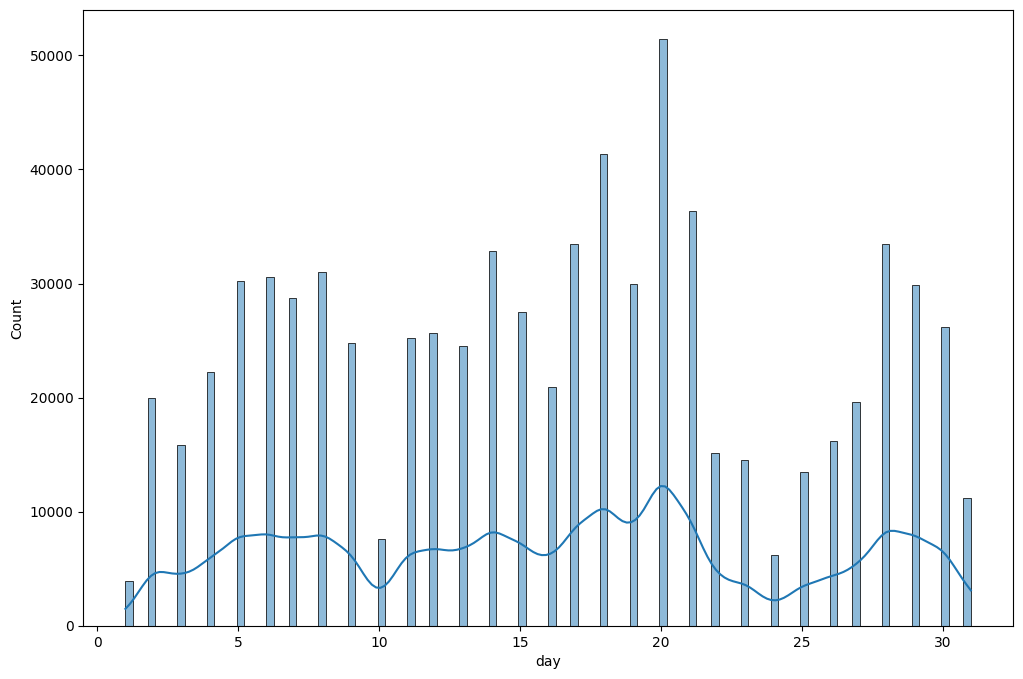

In [17]:
plt.figure(figsize=(12,8))
sns.histplot(data=train_df,
             x='day',
             color=color_pal[0],
             kde=True)
plt.show()

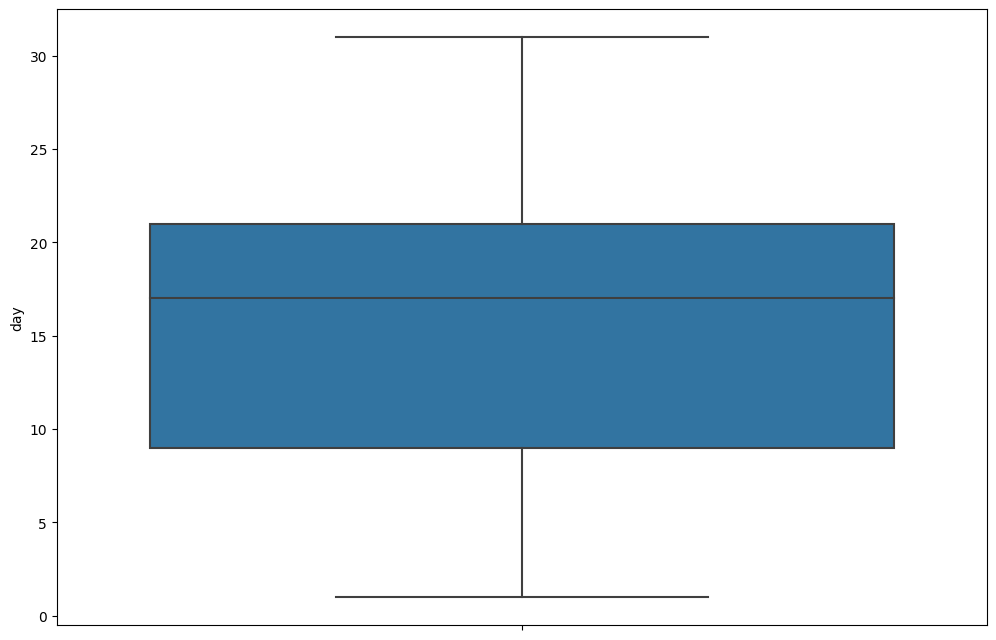

In [18]:
plt.figure(figsize=(12,8))
sns.boxplot( y='day', data=train_df)
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


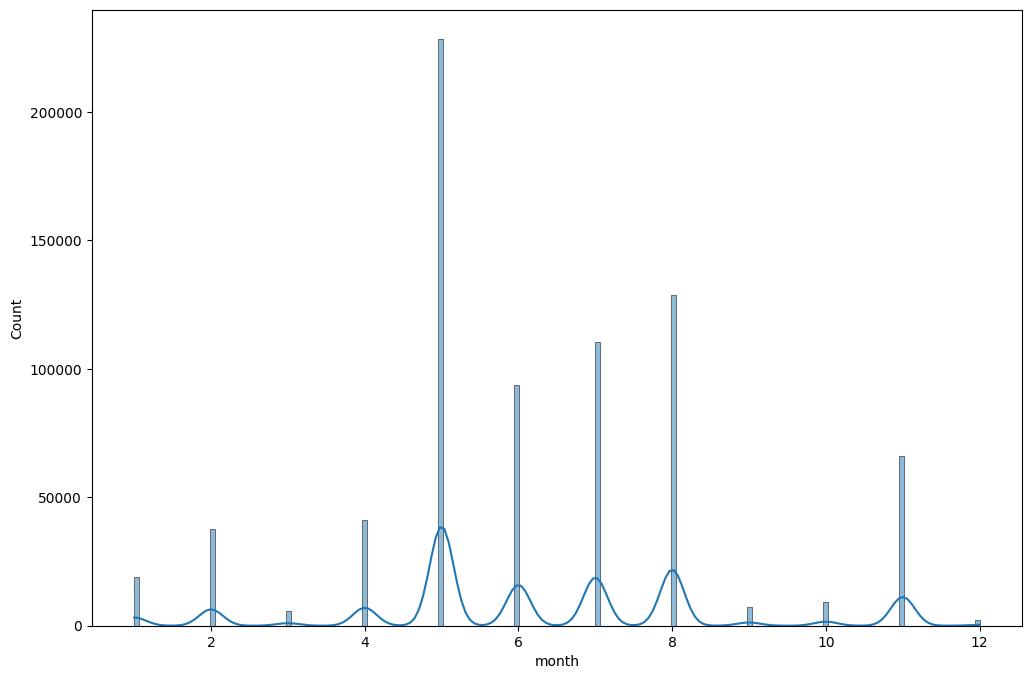

In [19]:
plt.figure(figsize=(12,8))
sns.histplot(data=train_df,
             x='month',
             color=color_pal[0],
             kde=True)
plt.show()

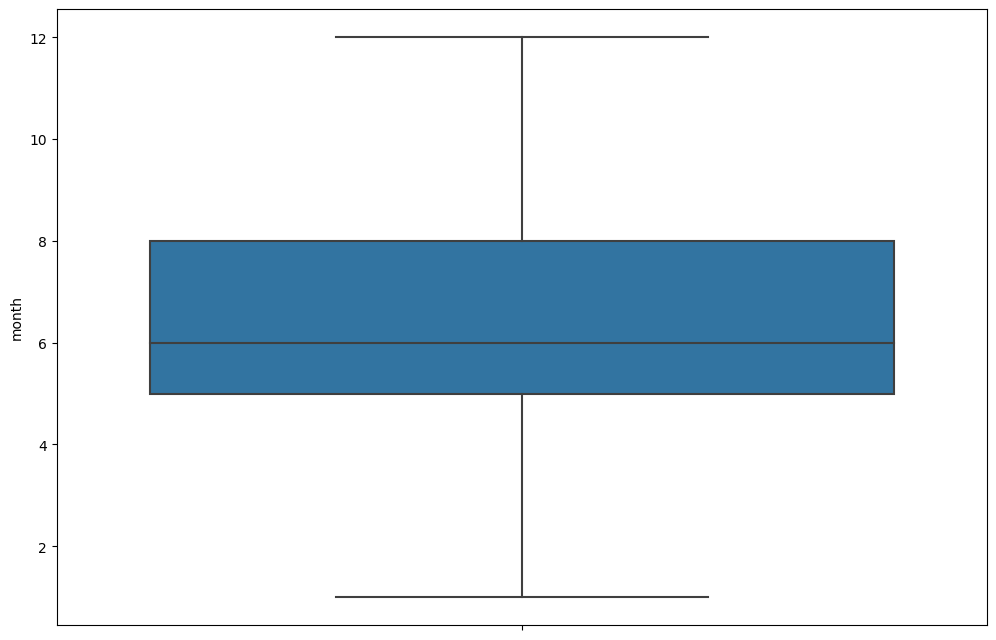

In [20]:
plt.figure(figsize=(12,8))
sns.boxplot( y='month', data=train_df)
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


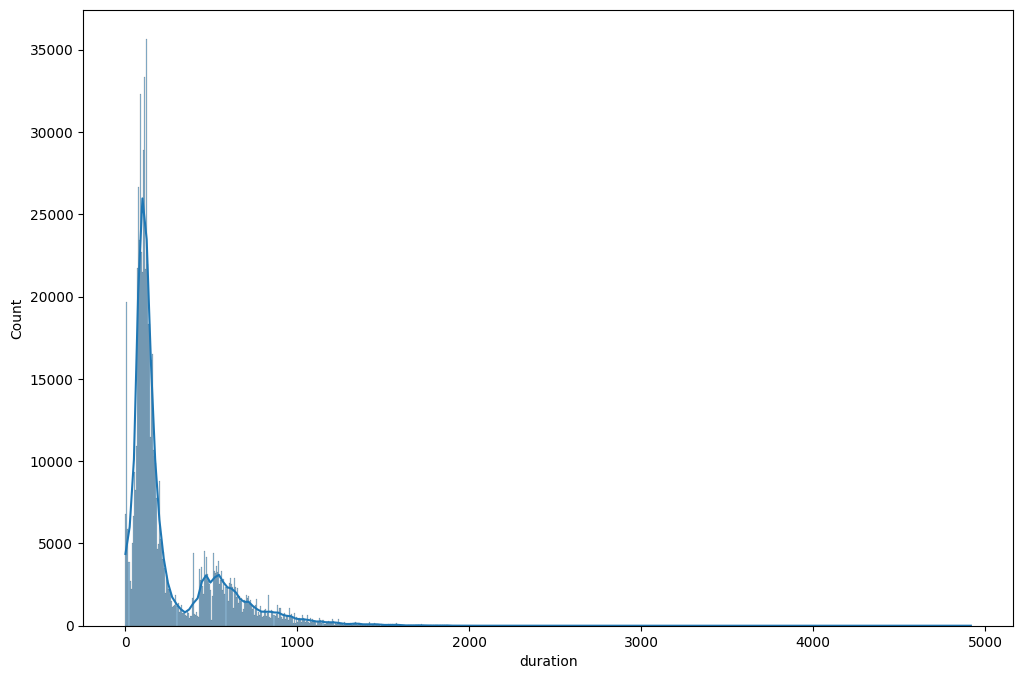

In [21]:
plt.figure(figsize=(12,8))
sns.histplot(data=train_df,
             x='duration',
             color=color_pal[0],
             kde=True)
plt.show()

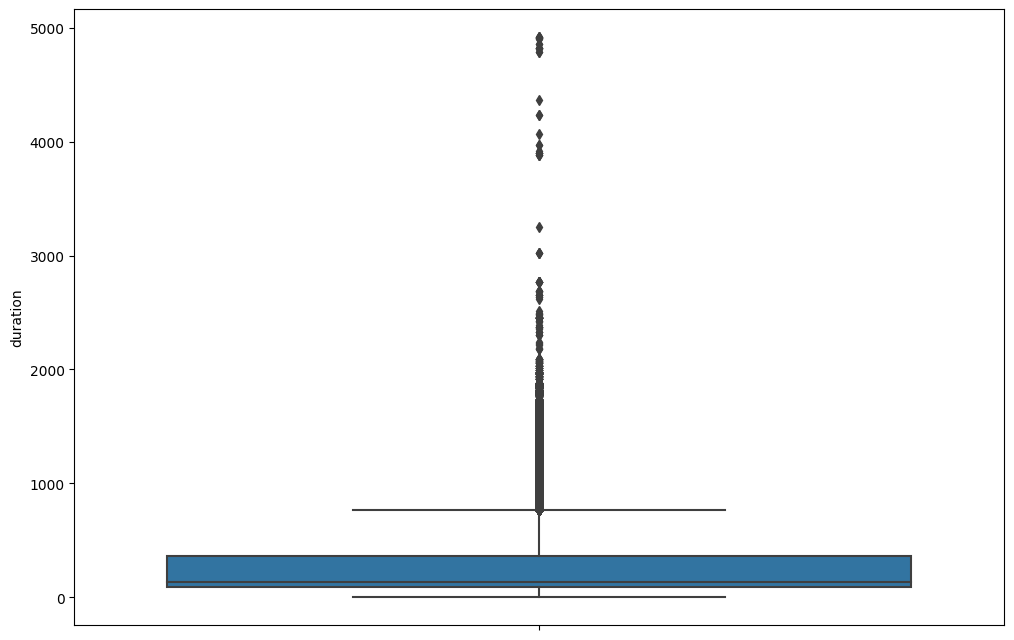

In [22]:
plt.figure(figsize=(12,8))
sns.boxplot( y='duration', data=train_df)
plt.show()

In [23]:
print(train_df.duration.nsmallest(10))
print(train_df.duration.nlargest(10))

47731     1
269221    1
298199    1
575563    1
648938    1
672102    1
490497    3
7591      4
9859      4
10642     4
Name: duration, dtype: int64
739177    4918
477980    4916
595734    4916
113334    4914
264264    4914
74126     4912
583357    4903
32085     4860
291128    4854
644556    4825
Name: duration, dtype: int64


In [24]:
train_df['duration_normalized'], lmbda= stats.boxcox(train_df['duration'])
test_df['duration_normalized'], lmbda= stats.boxcox(test_df['duration'])

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


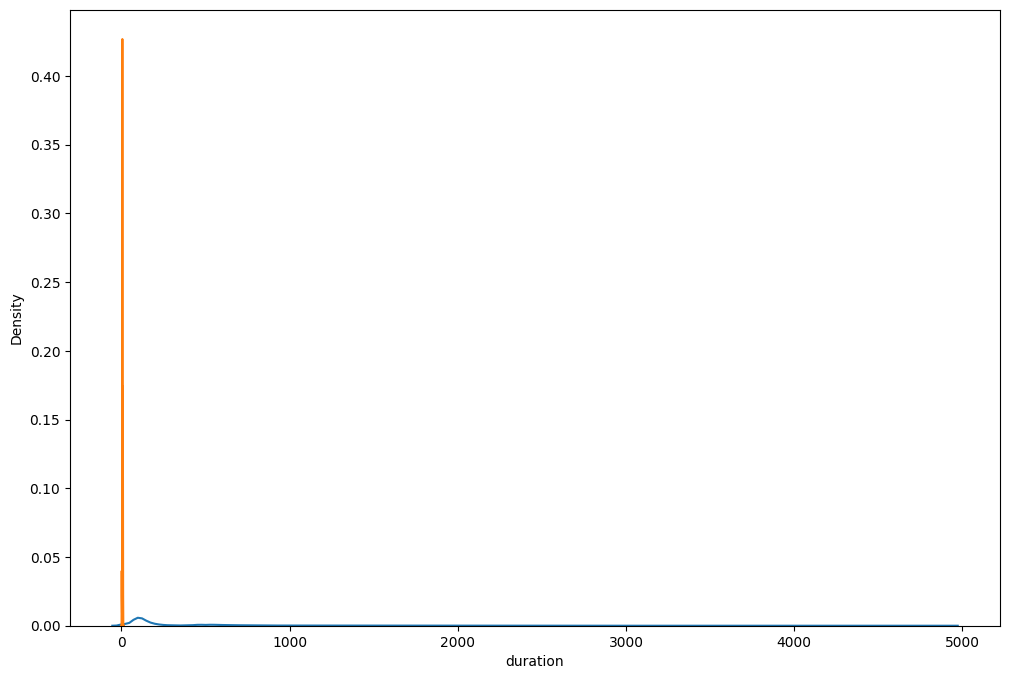

In [25]:
plt.figure(figsize=(12,8))
sns.kdeplot(data=train_df, x='duration', color=color_pal[0]) #azul
sns.kdeplot(data=train_df, x='duration_normalized', color=color_pal[1]) #naranja
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


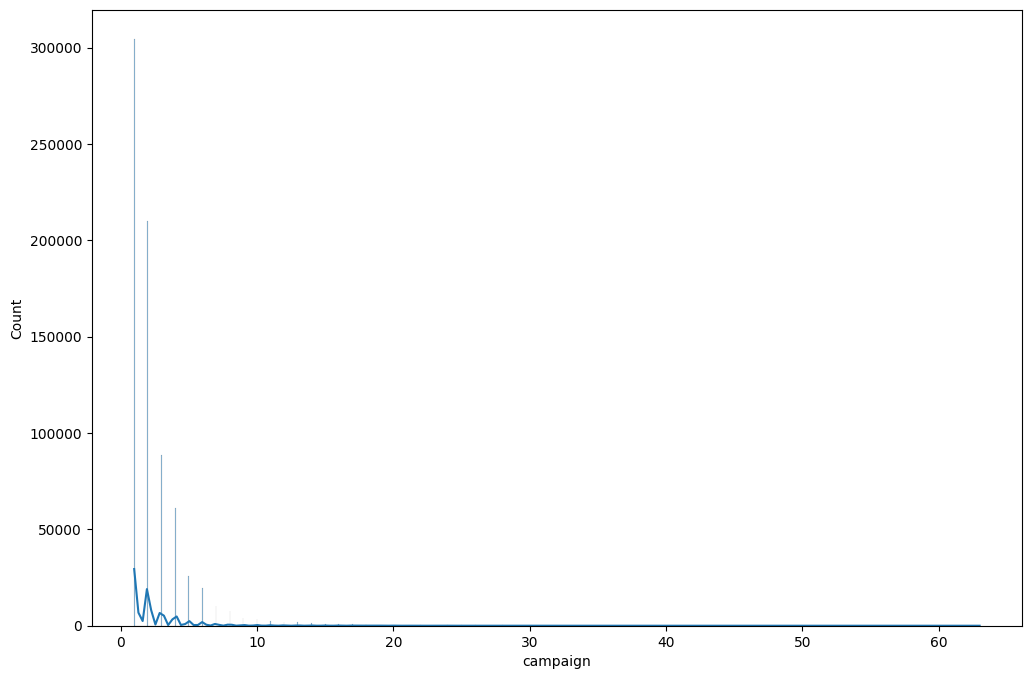

In [26]:
plt.figure(figsize=(12,8))
sns.histplot(data=train_df,
             x='campaign',
             color=color_pal[0],
             kde=True)
plt.show()

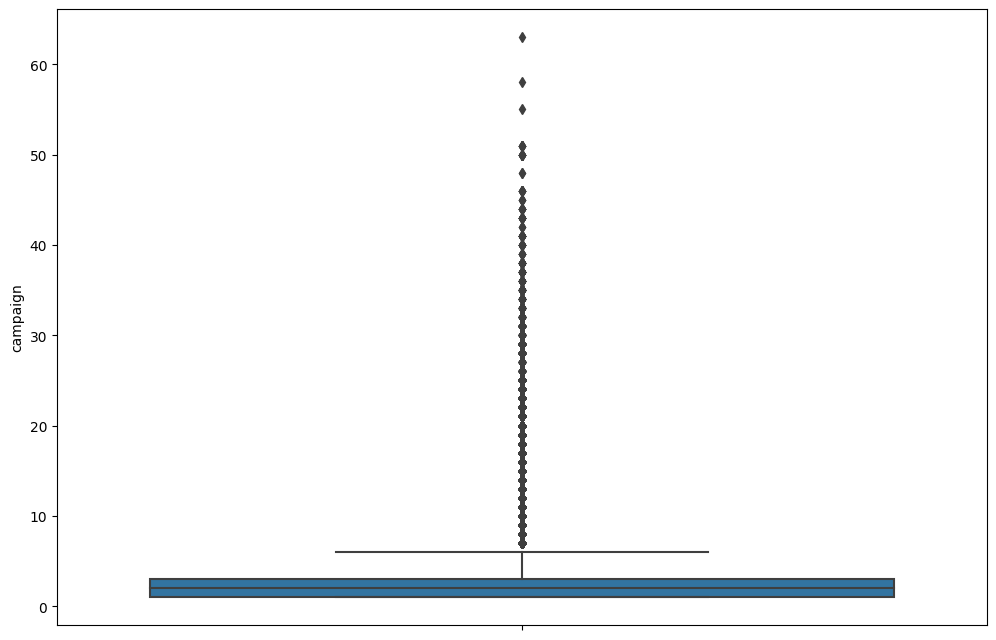

In [27]:
plt.figure(figsize=(12,8))
sns.boxplot( y='campaign', data=train_df)
plt.show()

In [28]:
print(train_df.campaign.nsmallest(10))
print(train_df.campaign.nlargest(10))

1     1
4     1
6     1
8     1
9     1
10    1
12    1
18    1
22    1
23    1
Name: campaign, dtype: int64
22290     63
215059    58
171760    55
27970     51
34662     51
70824     51
115060    51
282664    51
588424    51
695815    51
Name: campaign, dtype: int64


In [29]:
train_df['campaign_normalized'], lmbda= stats.boxcox(train_df['campaign'])
test_df['campaign_normalized'], lmbda= stats.boxcox(test_df['campaign'])

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


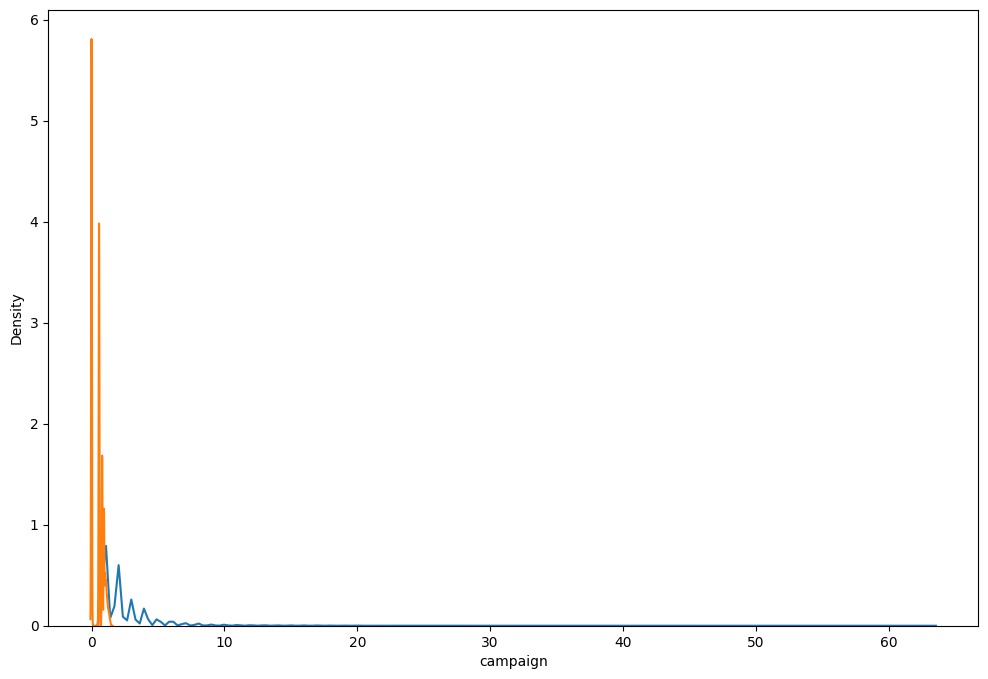

In [30]:
plt.figure(figsize=(12,8))
sns.kdeplot(data=train_df, x='campaign', color=color_pal[0]) #azul
sns.kdeplot(data=train_df, x='campaign_normalized', color=color_pal[1]) #naranja
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


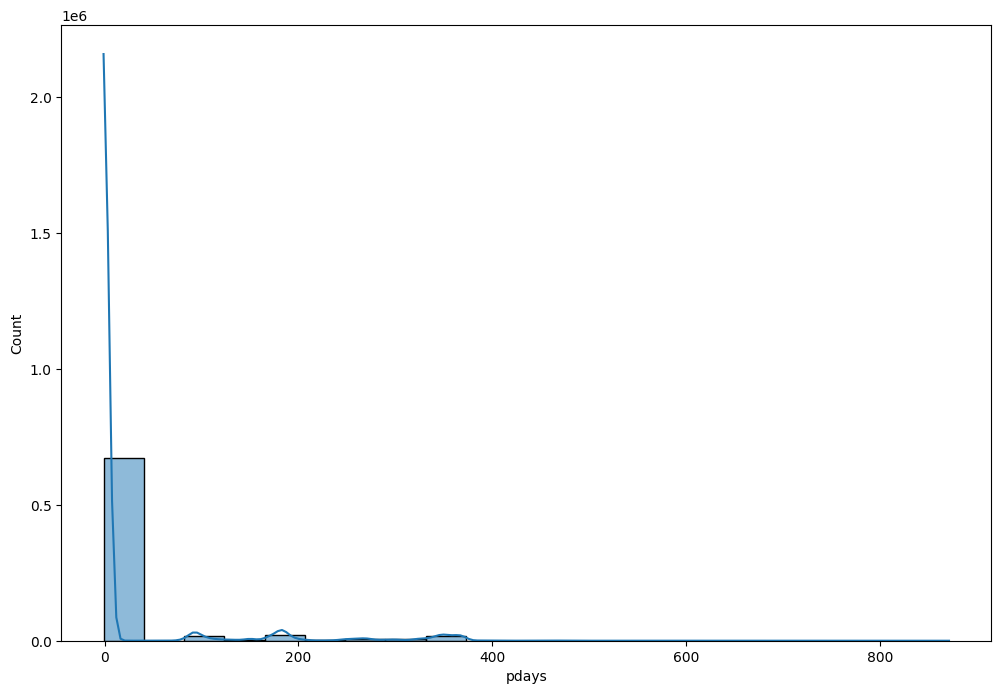

In [31]:
plt.figure(figsize=(12,8))
sns.histplot(data=train_df,
             x='pdays',
             color=color_pal[0],
             kde=True)
plt.show()

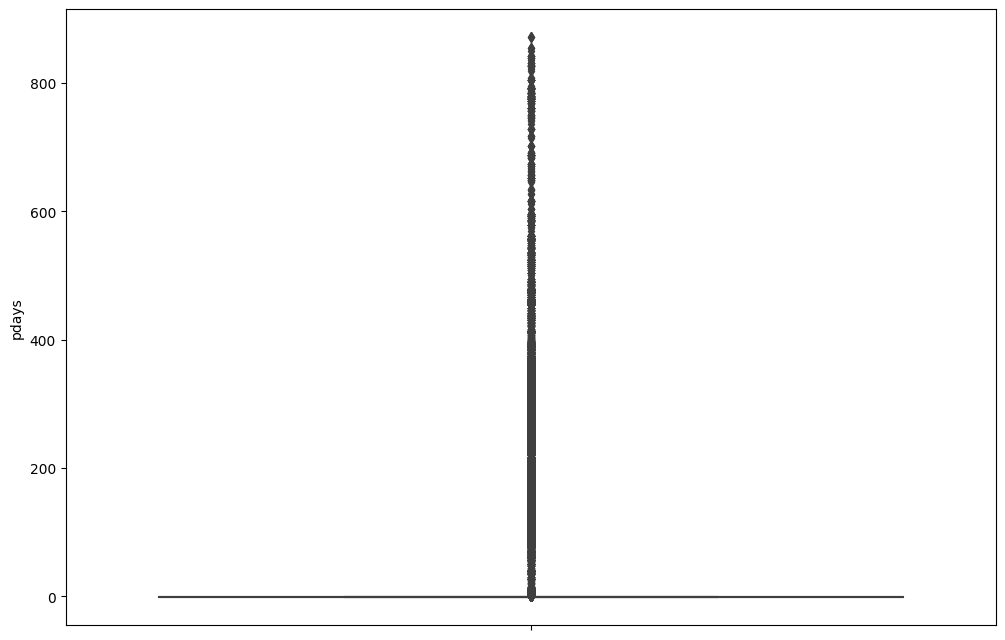

In [32]:
plt.figure(figsize=(12,8))
sns.boxplot( y='pdays', data=train_df)
plt.show()

In [33]:
print(train_df.pdays.nsmallest(10))
print(train_df.pdays.nlargest(10))

0   -1
1   -1
2   -1
3   -1
4   -1
5   -1
6   -1
7   -1
8   -1
9   -1
Name: pdays, dtype: int64
491713    871
647046    871
53984     854
552029    854
20525     850
11535     842
140895    842
227464    842
423424    842
438855    842
Name: pdays, dtype: int64


In [34]:
train_df['pdays_normalized'], lmbda= stats.yeojohnson(train_df['pdays'])
test_df['pdays_normalized'], lmbda= stats.yeojohnson(test_df['pdays'])

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


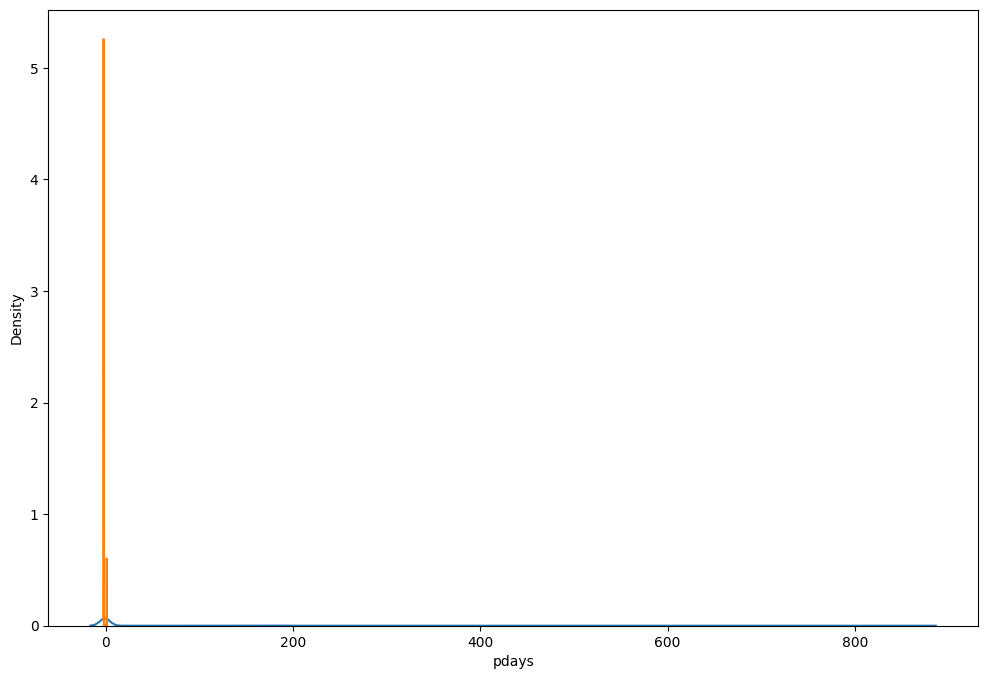

In [35]:
plt.figure(figsize=(12,8))
sns.kdeplot(data=train_df, x='pdays', color=color_pal[0]) #azul
sns.kdeplot(data=train_df, x='pdays_normalized', color=color_pal[1]) #naranja
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


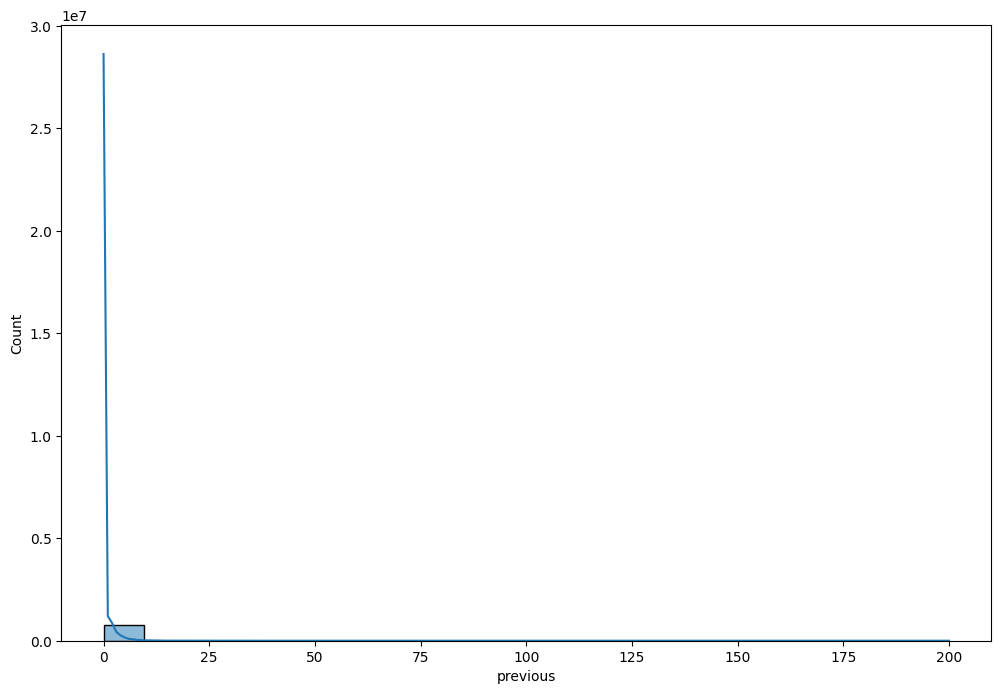

In [36]:
plt.figure(figsize=(12,8))
sns.histplot(data=train_df,
             x='previous',
             color=color_pal[0],
             kde=True)
plt.show()

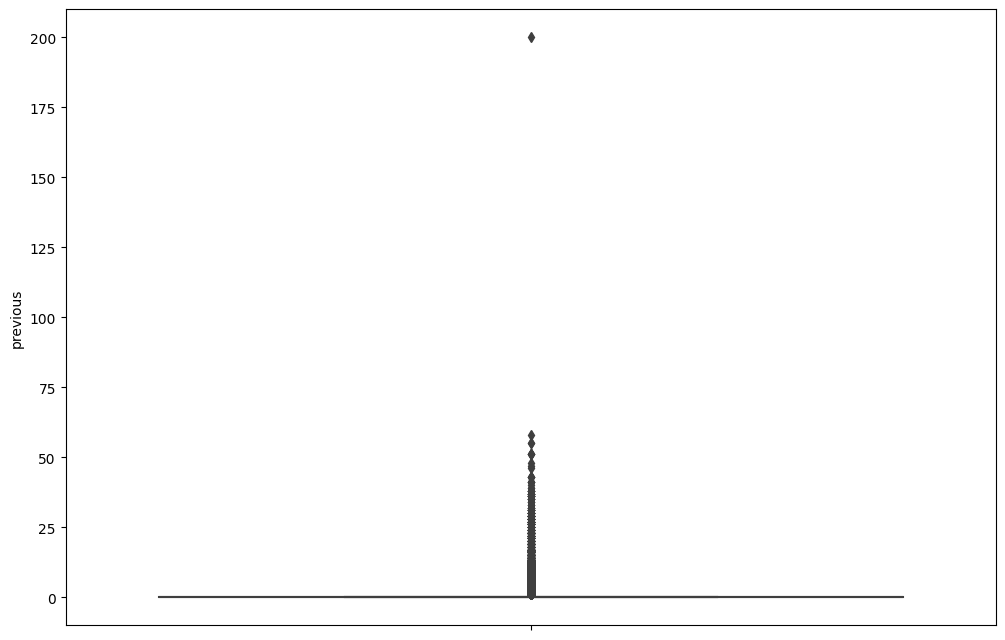

In [37]:
plt.figure(figsize=(12,8))
sns.boxplot( y='previous', data=train_df)
plt.show()

In [38]:
print(train_df.previous.nsmallest(10))
print(train_df.previous.nlargest(10))

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: previous, dtype: int64
537358    200
676977     58
15984      55
634638     55
75832      51
336079     51
350746     51
554809     51
602770     48
437224     47
Name: previous, dtype: int64


In [39]:
train_df['previous_normalized'], lmbda= stats.yeojohnson(train_df['previous'])
test_df['previous_normalized'], lmbda= stats.yeojohnson(test_df['previous'])

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


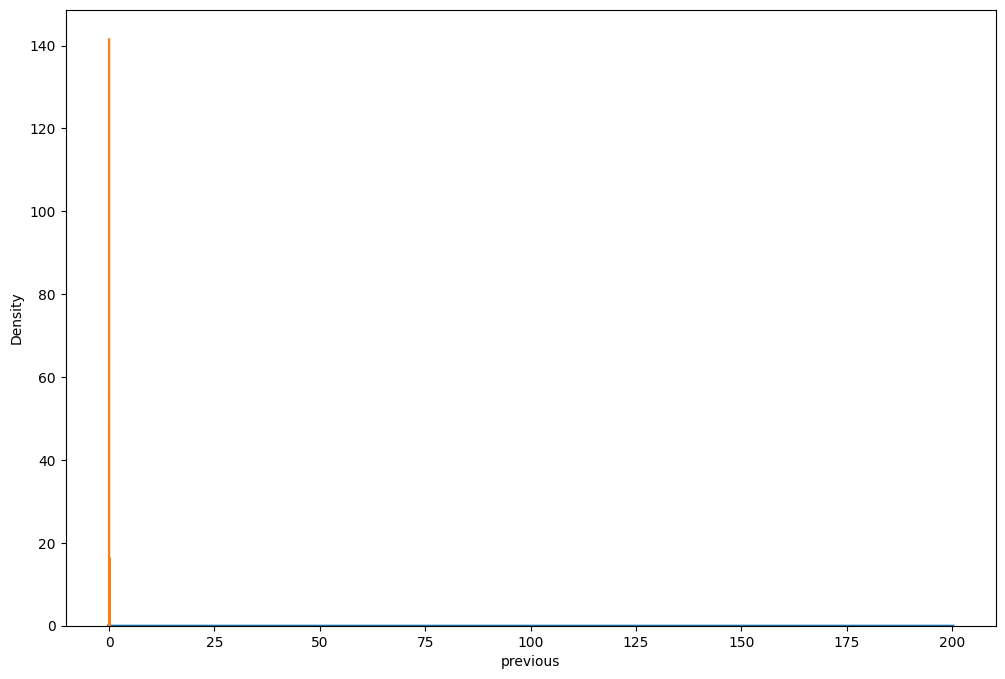

In [40]:
plt.figure(figsize=(12,8))
sns.kdeplot(data=train_df, x='previous', color=color_pal[0]) #azul
sns.kdeplot(data=train_df, x='previous_normalized', color=color_pal[1]) #naranja
plt.show()

In [41]:
train_df[train_df['previous'] == 200]

,id,age,job,marital,education,default,balance,housing,loan,contact,...,campaign,pdays,previous,poutcome,y,balance_normalized,duration_normalized,campaign_normalized,pdays_normalized,previous_normalized
537358,537358,27,technician,single,tertiary,no,0,no,no,cellular,...,1,100,200,other,0,0.0,2.16968,0.0,0.932377,0.124165


In [42]:
#Quitar datos nulos 
# calcular el número de datos nulos por columna
missing_values_count = train_df.isna().sum()
print(missing_values_count)

id                     0
age                    0
job                    0
marital                0
education              0
default                0
balance                0
housing                0
loan                   0
contact                0
day                    0
month                  0
duration               0
campaign               0
pdays                  0
previous               0
poutcome               0
y                      0
balance_normalized     0
duration_normalized    0
campaign_normalized    0
pdays_normalized       0
previous_normalized    0
dtype: int64


In [43]:
train_df['previous']=train_df['previous'].replace(200,np.nan)

In [44]:
train_df=train_df.dropna()

In [45]:
duplicated_values_count = train_df.duplicated().sum()
print(duplicated_values_count)

0


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

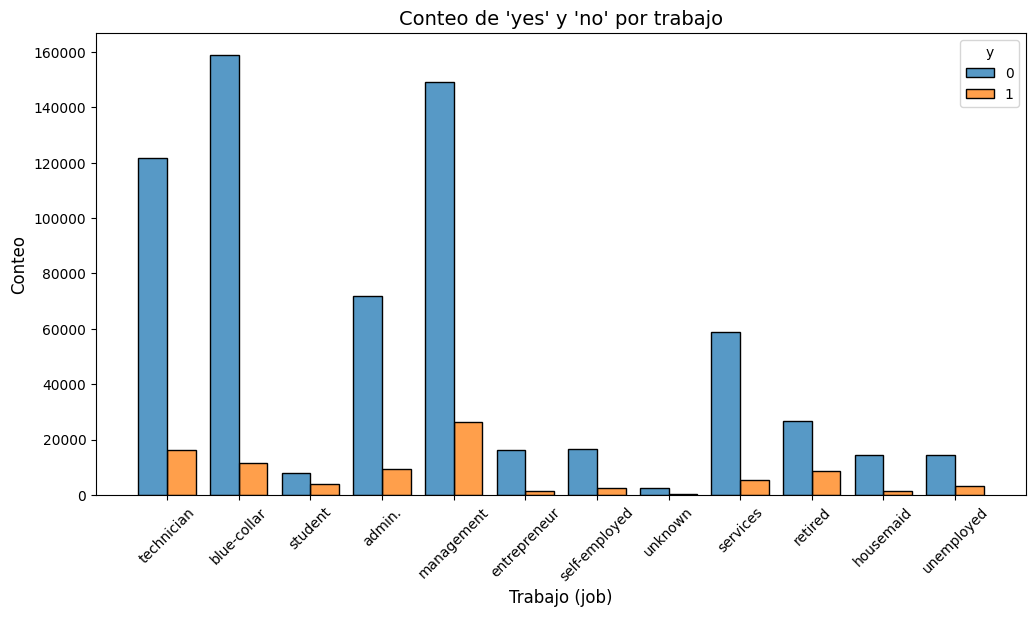

In [46]:
plt.figure(figsize=(12,6))
# Crear el gráfico
ax = sns.histplot(
    data=train_df,
    x="job",          # Variable categórica (eje X)
    hue="y",          # Variable binaria (yes/no)
    multiple="dodge", # Barras lado a lado (no apiladas)
    shrink=0.8,       # Controla el ancho de las barras (0.8=default, <1 más anchas)
    edgecolor="black", # Borde de las barras
    legend=True
)

# Personalizar
plt.title("Conteo de 'yes' y 'no' por trabajo", fontsize=14)
plt.xlabel("Trabajo (job)", fontsize=12)
plt.ylabel("Conteo", fontsize=12)
plt.xticks(rotation=45)  # Rotar etiquetas del eje X

plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

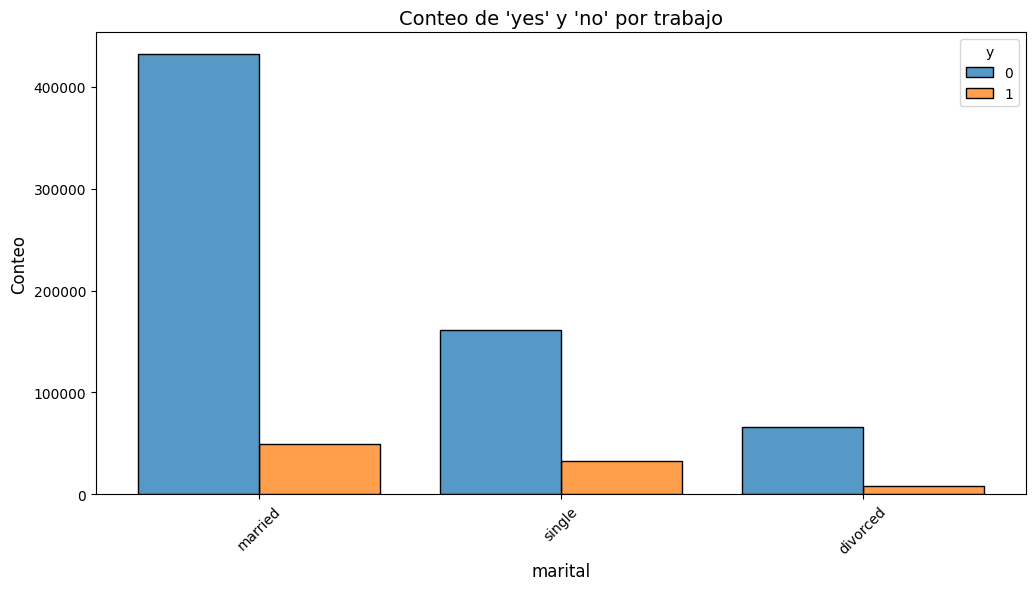

In [47]:
plt.figure(figsize=(12,6))
# Crear el gráfico
ax = sns.histplot(
    data=train_df,
    x="marital",          # Variable categórica (eje X)
    hue="y",          # Variable binaria (yes/no)
    multiple="dodge", # Barras lado a lado (no apiladas)
    shrink=0.8,       # Controla el ancho de las barras (0.8=default, <1 más anchas)
    edgecolor="black", # Borde de las barras
    legend=True
)

# Personalizar
plt.title("Conteo de 'yes' y 'no' por trabajo", fontsize=14)
plt.xlabel("marital", fontsize=12)
plt.ylabel("Conteo", fontsize=12)
plt.xticks(rotation=45)  # Rotar etiquetas del eje X

plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

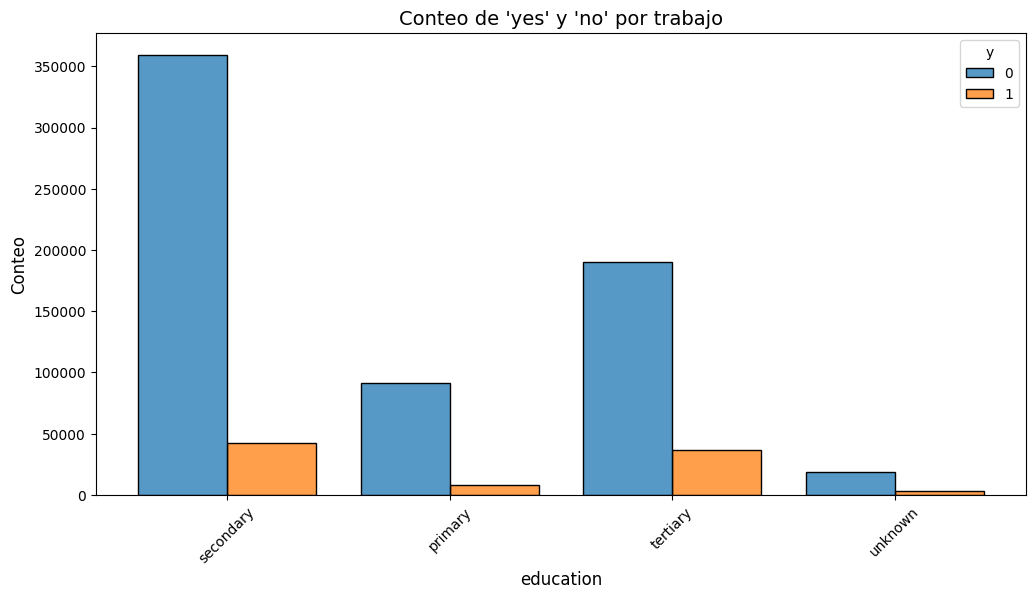

In [48]:
plt.figure(figsize=(12,6))
# Crear el gráfico
ax = sns.histplot(
    data=train_df,
    x="education",          # Variable categórica (eje X)
    hue="y",          # Variable binaria (yes/no)
    multiple="dodge", # Barras lado a lado (no apiladas)
    shrink=0.8,       # Controla el ancho de las barras (0.8=default, <1 más anchas)
    edgecolor="black", # Borde de las barras
    legend=True
)

# Personalizar
plt.title("Conteo de 'yes' y 'no' por trabajo", fontsize=14)
plt.xlabel("education", fontsize=12)
plt.ylabel("Conteo", fontsize=12)
plt.xticks(rotation=45)  # Rotar etiquetas del eje X

plt.show()

In [49]:
# Diccionario de mapeo
nivel_educación= {
    'secondary': 2, 'primary': 1, 'tertiary': 3, 'unknown': 0
}

train_df.education=train_df['education'].replace(nivel_educación).astype(int)
test_df.education=test_df['education'].replace(nivel_educación).astype(int)

/tmp/ipykernel_17/3010301528.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df.education=train_df['education'].replace(nivel_educación).astype(int)
/tmp/ipykernel_17/3010301528.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df.education=test_df['education'].replace(nivel_educación).astype(int)


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

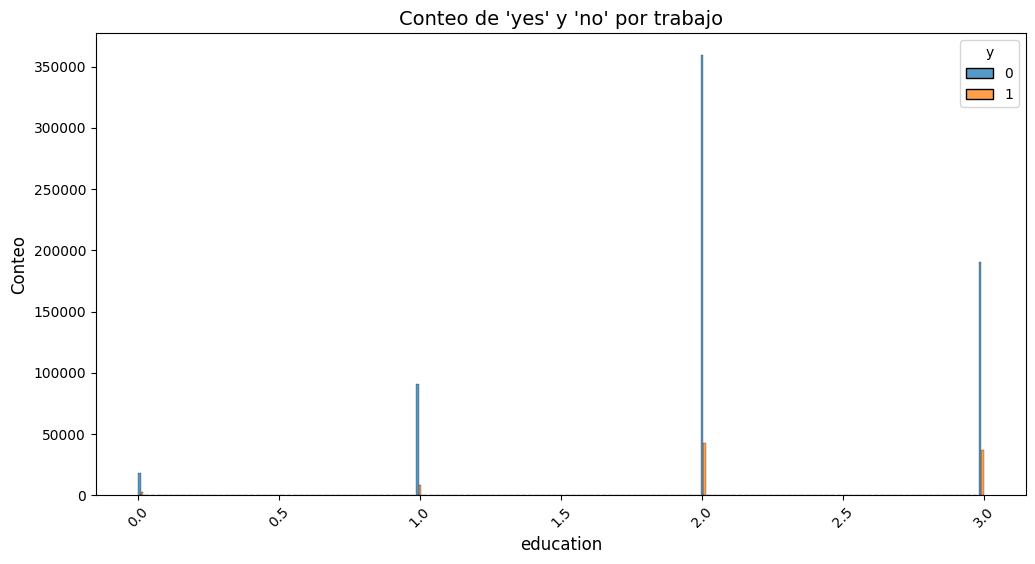

In [50]:

plt.figure(figsize=(12,6))
# Crear el gráfico
ax = sns.histplot(
    data=train_df,
    x="education",          # Variable categórica (eje X)
    hue="y",          # Variable binaria (yes/no)
    multiple="dodge", # Barras lado a lado (no apiladas)
    shrink=0.8,       # Controla el ancho de las barras (0.8=default, <1 más anchas)
    edgecolor="black", # Borde de las barras
    legend=True
)

# Personalizar
plt.title("Conteo de 'yes' y 'no' por trabajo", fontsize=14)
plt.xlabel("education", fontsize=12)
plt.ylabel("Conteo", fontsize=12)
plt.xticks(rotation=45)  # Rotar etiquetas del eje X

plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

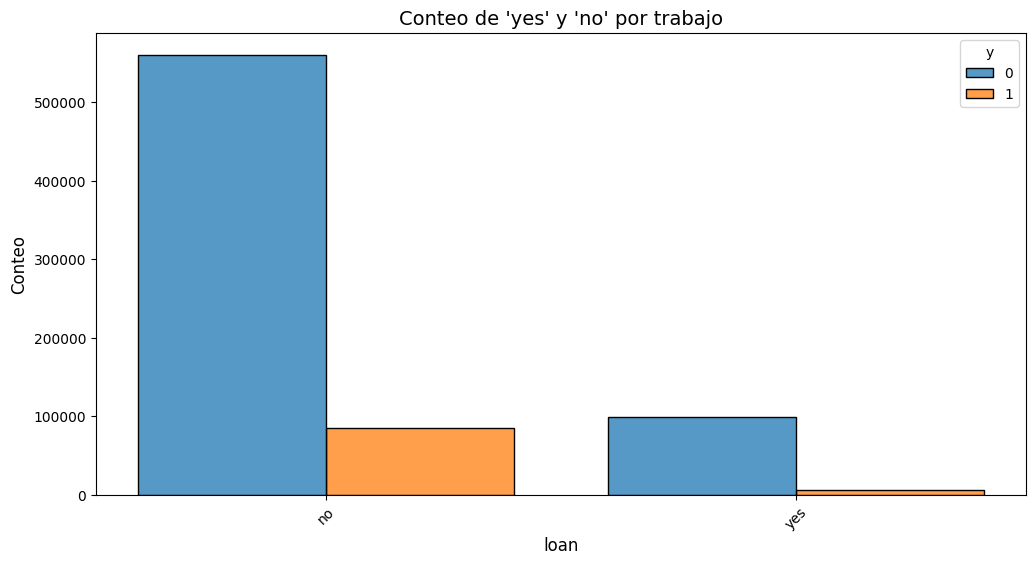

In [51]:
plt.figure(figsize=(12,6))
# Crear el gráfico
ax = sns.histplot(
    data=train_df,
    x="loan",          # Variable categórica (eje X)
    hue="y",          # Variable binaria (yes/no)
    multiple="dodge", # Barras lado a lado (no apiladas)
    shrink=0.8,       # Controla el ancho de las barras (0.8=default, <1 más anchas)
    edgecolor="black", # Borde de las barras
    legend=True
)

# Personalizar
plt.title("Conteo de 'yes' y 'no' por trabajo", fontsize=14)
plt.xlabel("loan", fontsize=12)
plt.ylabel("Conteo", fontsize=12)
plt.xticks(rotation=45)  # Rotar etiquetas del eje X

plt.show()

In [52]:
train_df.loan=train_df.loan.replace({'yes':1, 'no':0})
test_df.loan=test_df.loan.replace({'yes':1, 'no':0})

/tmp/ipykernel_17/4237072756.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df.loan=train_df.loan.replace({'yes':1, 'no':0})
/tmp/ipykernel_17/4237072756.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df.loan=test_df.loan.replace({'yes':1, 'no':0})


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

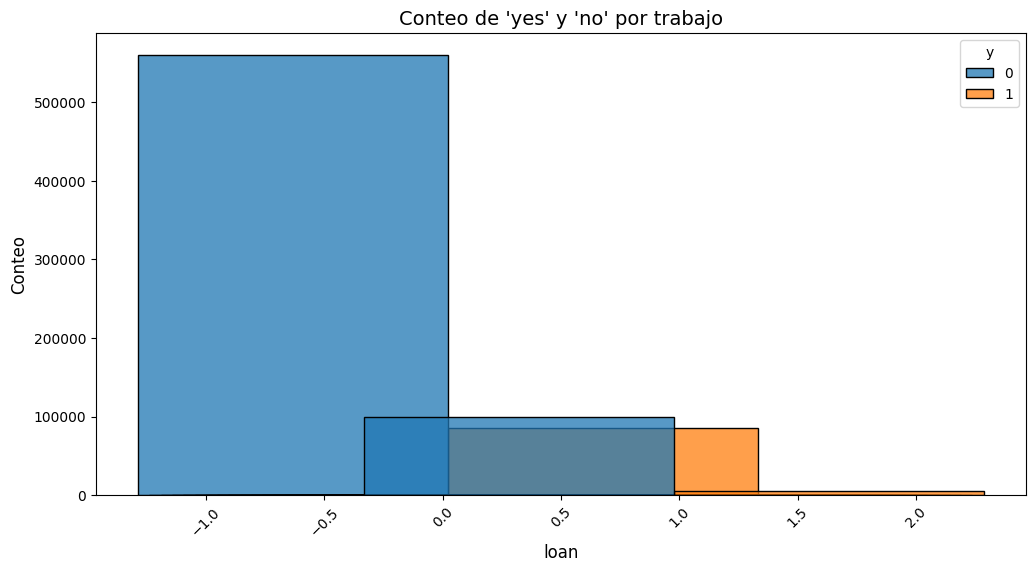

In [53]:

plt.figure(figsize=(12,6))
# Crear el gráfico
ax = sns.histplot(
    data=train_df,
    x="loan",          # Variable categórica (eje X)
    hue="y",          # Variable binaria (yes/no)
    multiple="dodge", # Barras lado a lado (no apiladas)
    shrink=55,       # Controla el ancho de las barras (0.8=default, <1 más anchas)
    edgecolor="black", # Borde de las barras
    legend=True
)

# Personalizar
plt.title("Conteo de 'yes' y 'no' por trabajo", fontsize=14)
plt.xlabel("loan", fontsize=12)
plt.ylabel("Conteo", fontsize=12)
plt.xticks(rotation=45)  # Rotar etiquetas del eje X

plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

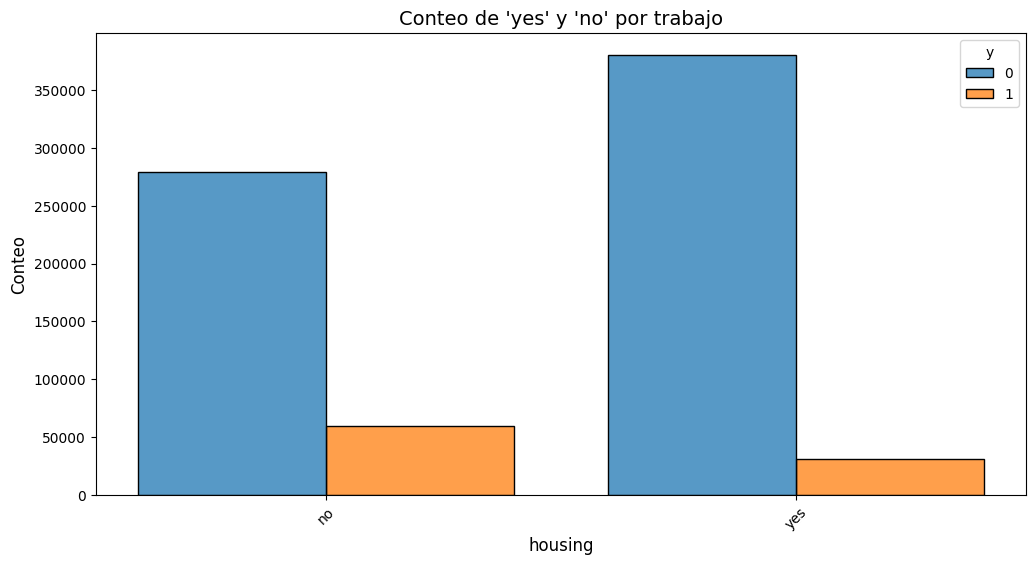

In [54]:
plt.figure(figsize=(12,6))
# Crear el gráfico
ax = sns.histplot(
    data=train_df,
    x="housing",          # Variable categórica (eje X)
    hue="y",          # Variable binaria (yes/no)
    multiple="dodge", # Barras lado a lado (no apiladas)
    shrink=0.8,       # Controla el ancho de las barras (0.8=default, <1 más anchas)
    edgecolor="black", # Borde de las barras
    legend=True
)

# Personalizar
plt.title("Conteo de 'yes' y 'no' por trabajo", fontsize=14)
plt.xlabel("housing", fontsize=12)
plt.ylabel("Conteo", fontsize=12)
plt.xticks(rotation=45)  # Rotar etiquetas del eje X

plt.show()

In [55]:
train_df['housing']=train_df['housing'].replace({'yes':1, 'no':0})
test_df['housing']=test_df['housing'].replace({'yes':1, 'no':0})

/tmp/ipykernel_17/2750466179.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_df['housing']=train_df['housing'].replace({'yes':1, 'no':0})
/tmp/ipykernel_17/2750466179.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df['housing']=test_df['housing'].replace({'yes':1, 'no':0})


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

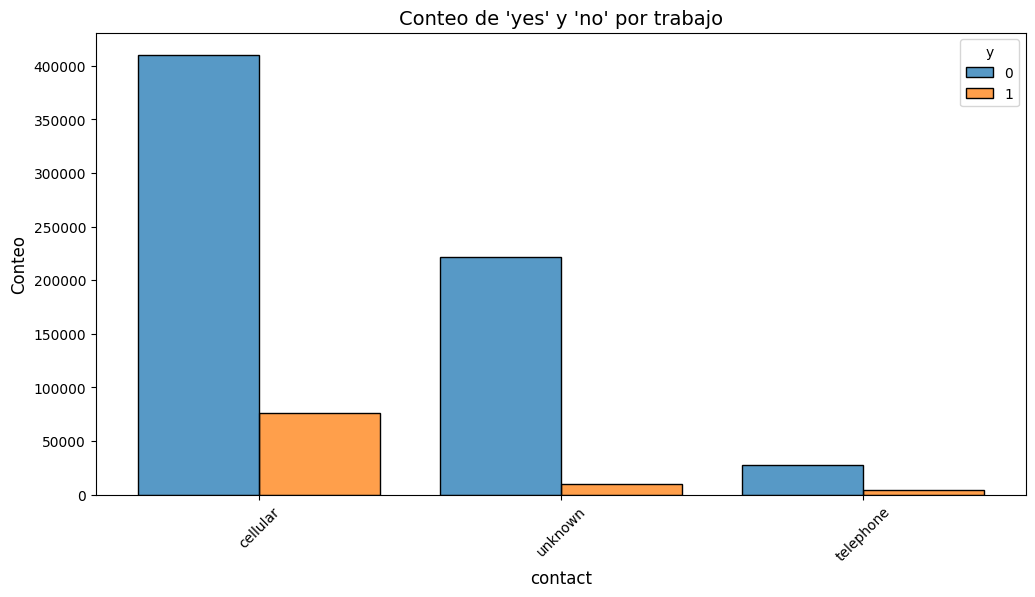

In [56]:
plt.figure(figsize=(12,6))
# Crear el gráfico
ax = sns.histplot(
    data=train_df,
    x="contact",          # Variable categórica (eje X)
    hue="y",          # Variable binaria (yes/no)
    multiple="dodge", # Barras lado a lado (no apiladas)
    shrink=0.8,       # Controla el ancho de las barras (0.8=default, <1 más anchas)
    edgecolor="black", # Borde de las barras
    legend=True
)

# Personalizar
plt.title("Conteo de 'yes' y 'no' por trabajo", fontsize=14)
plt.xlabel("contact", fontsize=12)
plt.ylabel("Conteo", fontsize=12)
plt.xticks(rotation=45)  # Rotar etiquetas del eje X

plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

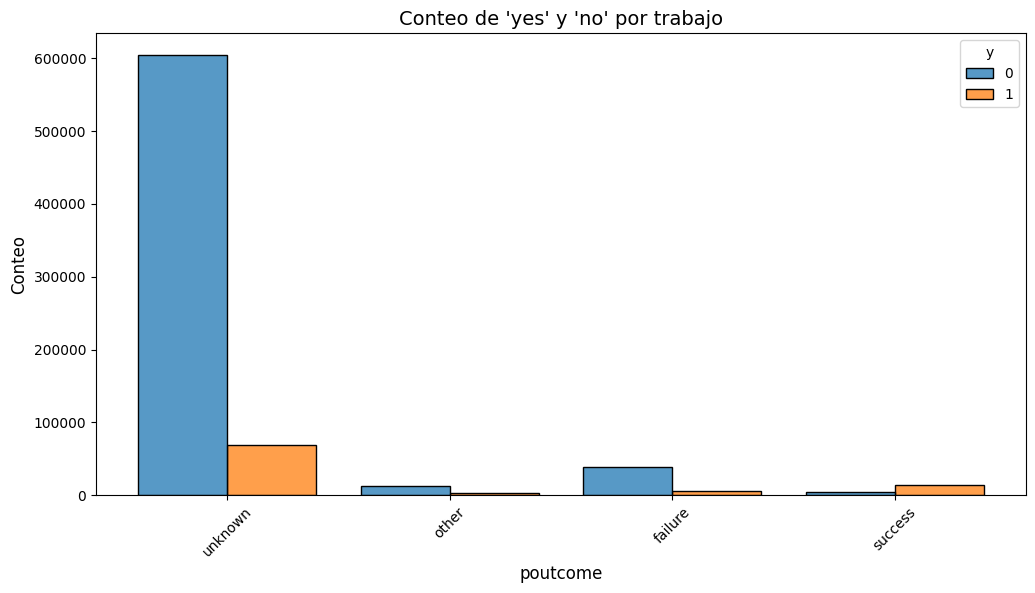

In [57]:
plt.figure(figsize=(12,6))
# Crear el gráfico
ax = sns.histplot(
    data=train_df,
    x="poutcome",          # Variable categórica (eje X)
    hue="y",          # Variable binaria (yes/no)
    multiple="dodge", # Barras lado a lado (no apiladas)
    shrink=0.8,       # Controla el ancho de las barras (0.8=default, <1 más anchas)
    edgecolor="black", # Borde de las barras
    legend=True
)

# Personalizar
plt.title("Conteo de 'yes' y 'no' por trabajo", fontsize=14)
plt.xlabel("poutcome", fontsize=12)
plt.ylabel("Conteo", fontsize=12)
plt.xticks(rotation=45)  # Rotar etiquetas del eje X

plt.show()

# Transformación

In [58]:
#pasar variable categóricas a numéricas con onehotimputer
train_df.dtypes

id                       int64
age                      int64
job                     object
marital                 object
education                int64
default                 object
balance                  int64
housing                  int64
loan                     int64
contact                 object
day                      int64
month                    int64
duration                 int64
campaign                 int64
pdays                    int64
previous               float64
poutcome                object
y                        int64
balance_normalized     float64
duration_normalized    float64
campaign_normalized    float64
pdays_normalized       float64
previous_normalized    float64
dtype: object

In [59]:
#se guarda el dataset
#train_df.to_parquet("train_df.parquet", index=False, engine="fastparquet")

In [60]:
s = (train_df.dtypes == 'object')
object_cols = list(s[s].index)
print("Variables categóricas:")
print(object_cols)

Variables categóricas:
['job', 'marital', 'default', 'contact', 'poutcome']


In [61]:
from sklearn.preprocessing import OneHotEncoder
OH_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
OH_cols_train = pd.DataFrame(OH_encoder.fit_transform(train_df[object_cols]))
OH_cols_test = pd.DataFrame(OH_encoder.fit_transform(test_df[object_cols]))

# Obtener los nombres de las nuevas columnas
new_columns = OH_encoder.get_feature_names_out(object_cols)
OH_cols_train.columns = new_columns
OH_cols_test.columns = new_columns

OH_cols_train.index = train_df.index
OH_cols_test.index = test_df.index

#Eliminar las variables categóricas del dataframe 
num_x_train = train_df.drop(object_cols, axis=1)
num_x_test = test_df.drop(object_cols, axis=1)

#Unir las nuevas variables numericas al dataframe anterior
OH_x_train = pd.concat([num_x_train, OH_cols_train], axis=1)
OH_x_test = pd.concat([num_x_test, OH_cols_test], axis=1)

#Convertir el nombre de las columnas en strings
OH_x_train.columns = OH_x_train.columns.astype(str)
OH_x_test.columns = OH_x_test.columns.astype(str)


In [62]:
OH_x_train.dtypes

id                       int64
age                      int64
education                int64
balance                  int64
housing                  int64
loan                     int64
day                      int64
month                    int64
duration                 int64
campaign                 int64
pdays                    int64
previous               float64
y                        int64
balance_normalized     float64
duration_normalized    float64
campaign_normalized    float64
pdays_normalized       float64
previous_normalized    float64
job_admin.             float64
job_blue-collar        float64
job_entrepreneur       float64
job_housemaid          float64
job_management         float64
job_retired            float64
job_self-employed      float64
job_services           float64
job_student            float64
job_technician         float64
job_unemployed         float64
job_unknown            float64
marital_divorced       float64
marital_married        float64
marital_

In [63]:
y_train = OH_x_train['y']
x_train = OH_x_train.drop(['y', 'id'], axis=1)
x_test = test_df.drop('id', axis=1)

In [64]:
#se guarda el dataset
#x_train.to_parquet("x_train.parquet", index=False, engine="fastparquet")
#joblib.dump(y_train,"y_train.joblib")
#x_test.to_parquet("x_test.parquet", index=False, engine="fastparquet")
#OH_x_train.to_parquet("OH_x_train.parquet", index=False, engine="fastparquet")
#test_df.to_parquet("test_df.parquet", index=False, engine="fastparquet")


## Regresion lineal

In [65]:
from sklearn.linear_model import LinearRegression
regresionLineal = LinearRegression()
modellineal = regresionLineal.fit(x_train.sort_index(),
                                  y_train.sort_index())
# Show the equation values:
print("Intercept :",    modellineal.intercept_.round(3))

coefficient_dict = dict(zip(x_train.columns,
                            modellineal.coef_))
print("Coefficients :")
for feature, coef in coefficient_dict.items():
    print(f"{feature}: {coef:.3f}")

Intercept : 0.351
Coefficients :
age: -0.000
education: 0.011
balance: 0.000
housing: -0.060
loan: -0.038
day: -0.000
month: -0.005
duration: 0.001
campaign: 0.003
pdays: -0.000
previous: 0.002
balance_normalized: 0.000
duration_normalized: -0.012
campaign_normalized: -0.060
pdays_normalized: 0.083
previous_normalized: -0.764
job_admin.: 0.003
job_blue-collar: -0.022
job_entrepreneur: -0.028
job_housemaid: -0.029
job_management: 0.003
job_retired: 0.051
job_self-employed: -0.020
job_services: -0.017
job_student: 0.105
job_technician: -0.007
job_unemployed: -0.021
job_unknown: -0.017
marital_divorced: -0.010
marital_married: -0.007
marital_single: 0.017
default_no: -0.003
default_yes: 0.003
contact_cellular: 0.022
contact_telephone: 0.018
contact_unknown: -0.040
poutcome_failure: -0.145
poutcome_other: -0.135
poutcome_success: 0.334
poutcome_unknown: -0.054


In [66]:
#guardo el modelo 
#joblib.dump(modellineal,"modellineal.joblib")

In [67]:
modellineal_y = pd.DataFrame(modellineal.predict(x_train.sort_index()), 
                      index=x_train.index, 
                      columns=['lineal Model'])

print("Quality predicted value for the frst case:", modellineal_y.sort_index().head(1))

Quality predicted value for the frst case:    lineal Model
0       0.03845


### Grafico de datos predichos vs reales NO TIENE MUCHO SINTIDO SI NO SON VALORES NUMERICOS CONTINUOS

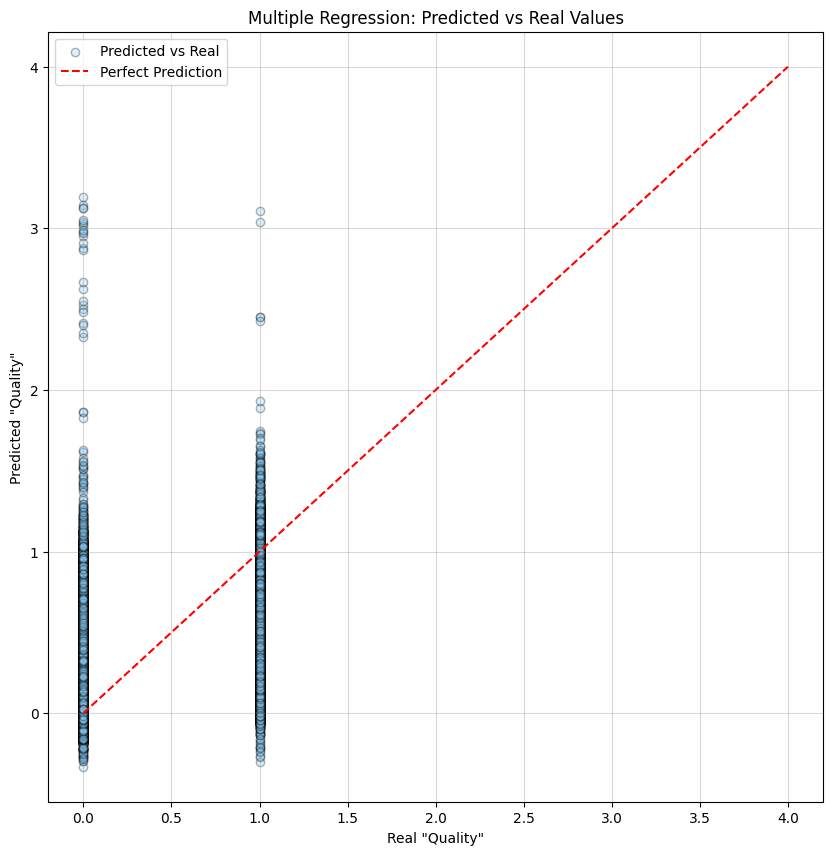

In [68]:
plt.figure(figsize=(10, 10))


# Plot model 2
plt.scatter(y_train.sort_index(),     # Real value
            modellineal_y.sort_index(),      # Predicted
            color='lightskyblue',
            edgecolor = "black",
            label='Predicted vs Real',
            alpha = 0.3)

# Plot a diagonal line representing perfect predictions and customize
plt.plot([0, 4], [0, 4], 
         color='red', 
         linestyle='--', 
         label='Perfect Prediction')

plt.xlabel('Real "Quality"')
plt.ylabel('Predicted "Quality"')
plt.title('Multiple Regression: Predicted vs Real Values')
plt.legend()
plt.grid(color = "gray",
         alpha = 0.3)



## Modelo Nulo

In [69]:
from sklearn.dummy import DummyRegressor

regression0 = DummyRegressor(strategy='mean')

# Fit the model
model0 = regression0.fit(x_train.sort_index(),
                         y_train.sort_index())

# Predicted value (same for all cases)
model0_y = model0.predict(x_train.sort_index())
print("Quality predicted value (same for all cases):", model0_y.round(3))

Quality predicted value (same for all cases): [0.121 0.121 0.121 ... 0.121 0.121 0.121]


In [70]:
# Modelos básicos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Modelos avanzados  
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier



## Regresion logística

In [71]:
regresionLogistica = LogisticRegression(max_iter=10000,
                                       class_weight='balanced',
                                n_jobs=8)
modellogi = regresionLogistica.fit(x_train.sort_index(),
                                  y_train.sort_index())


In [72]:
# Show the equation values:
print("Intercept :",    modellogi.intercept_.round(3))

coefficient_dict = dict(zip(x_train.columns,
                            modellogi.coef_[0]))
print("Coefficients :")
for feature, coef in coefficient_dict.items():
    print(f"{feature}: {coef:.3f}")

Intercept : [-1.025]
Coefficients :
age: -0.015
education: 0.025
balance: -0.000
housing: -0.991
loan: -0.955
day: -0.009
month: -0.091
duration: 0.003
campaign: 0.044
pdays: -0.005
previous: 0.009
balance_normalized: 0.001
duration_normalized: 0.696
campaign_normalized: -1.030
pdays_normalized: 0.671
previous_normalized: -0.067
job_admin.: 0.049
job_blue-collar: -0.627
job_entrepreneur: -0.276
job_housemaid: -0.282
job_management: 0.014
job_retired: 0.854
job_self-employed: -0.179
job_services: -0.526
job_student: 0.486
job_technician: -0.183
job_unemployed: -0.320
job_unknown: -0.035
marital_divorced: -0.337
marital_married: -0.486
marital_single: -0.202
default_no: -0.904
default_yes: -0.120
contact_cellular: -0.044
contact_telephone: 0.377
contact_unknown: -1.357
poutcome_failure: -1.331
poutcome_other: -0.658
poutcome_success: 1.448
poutcome_unknown: -0.485


In [73]:
#joblib.dump(modellogi,"modellogi.joblib")

## Random Forest Classifier

In [74]:

from sklearn.ensemble import RandomForestClassifier

# Configuración del Random Forest adaptada a tus parámetros
randomForest = RandomForestClassifier(
    n_estimators=100, #Número de árboles en el bosque (100 es el estándar por defecto)
    class_weight='balanced',    # Mantiene el mismo criterio de balanceo de clases
    n_jobs=8,                  # Sigue utilizando tus 8 núcleos en paralelo
    random_state=42            # Te asegura que el modelo sea reproducible
)

# Entrenamiento siguiendo tu misma lógica de ordenamiento por índice
modelRF = randomForest.fit(x_train.sort_index(), y_train.sort_index())

## Gradient Boosting Classifier

## SVC

## XGBClassifier

## LGBMClassifier

## MLPClassifier